In [46]:
import numpy as np
import scipy as sp

import cvxpy as cvx

In [47]:
n = 1000
m = 100
rng = np.random.default_rng()
A = rng.standard_normal(size=(m, n))
Sigma = rng.standard_normal(size=(n, n)) / np.sqrt(n)
Sigma = Sigma.T @ Sigma + np.eye(n)
b = rng.standard_normal(size=(m,1))


In [48]:
n = np.shape(A)[1]
n

1000

In [49]:
np.linalg.cond(Sigma)

4.925706670467774

In [50]:
np.linalg.cond(A)

1.8801789920924894

In [51]:
def project_onto_hyperplane(A, x, b):
    n = np.shape(x)[0]
    big_mat = np.block([[np.eye(n), -A.T], [A, np.zeros(shape=(m,m))]])
    sol = np.linalg.solve(big_mat, np.block([[x],[b]]))
    return sol[0:n]

In [52]:
def project_onto_sketched_hyperplane(A, x, b, sketch_size):
    rng = np.random.default_rng()
    n = np.shape(A)[1]
    m = np.shape(A)[0]
    S = rng.standard_normal(size=(n, sketch_size))

    # z = cvx.Variable( (sketch_size,1) )
    # cost = cvx.norm(S @ z - x)
    # constraints = [A @ S @ z == b]
    # prob = cvx.Problem(cvx.Minimize(cost), constraints)
    # prob.solve()
    # if prob.status == 'infeasible':
    #     print('NOT FEASIBLE')
    # z = np.matrix.view(z.value)
    # return S @ z
    # print(A.shape)
    # print(S.shape)+ np.eye(m + sketch_size, m+sketch_size)
    # biiifdsnf = A @ S
    big_mat = np.block([[S.T @ S, - S.T @ A.T], [A @ S, np.zeros(shape=(m,m))]])
    sol = np.linalg.lstsq(big_mat, np.block([[S.T @ x],[b]]))[0]
    return S @ sol[0:sketch_size]

In [53]:
def unsketched_admm(Sigma, A, max_iter, rho):
    costs = np.zeros(shape=(max_iter,1))
    feas = np.zeros(shape=(max_iter,1))
    admm_res = np.zeros(shape=(max_iter,1))

    x = np.zeros(shape=(n,1))
    y = np.zeros(shape=(n,1))
    u = np.zeros(shape=(n,1))

    for i in range(max_iter):
        x = np.linalg.solve(rho * Sigma + np.eye(n), y - u)
        y = project_onto_hyperplane(A, x + u, b)
        u = x - y + u

        costs[i] = x.T @ Sigma @ x / 2
        feas[i] = np.linalg.norm(A @ y - b)
        admm_res[i] = np.linalg.norm(x-y)
    return costs, feas, admm_res

In [54]:
def sketched_admm(Sigma, A, max_iter, rho):
    costs = np.zeros(shape=(max_iter,1))
    feas = np.zeros(shape=(max_iter,1))
    admm_res = np.zeros(shape=(max_iter,1))

    x = np.zeros(shape=(n,1))
    y = np.zeros(shape=(n,1))
    u = np.zeros(shape=(n,1))

    for i in range(max_iter):
        sketch_size = np.random.randint(m,n)
        x = np.linalg.solve(rho * Sigma + np.eye(n), y - u)
        y = project_onto_sketched_hyperplane(A, x + u, b, sketch_size)
        u = x - y + u

        costs[i] = x.T @ Sigma @ x / 2
        feas[i] = np.linalg.norm(A @ x - b)
        admm_res[i] = np.linalg.norm(x-y)
    return costs, feas, admm_res

In [55]:
max_iter = 1000
rho = 1

costs, feas, admm_res = unsketched_admm(Sigma, A, max_iter, rho)

print(costs[max_iter-1])
print(feas[max_iter-1])
print(admm_res[max_iter-1])

[0.10539467]
[5.05176668e-14]
[2.5857445e-14]


In [56]:
sketch_costs, sketch_feas, sketch_admm_res = sketched_admm(Sigma, A, max_iter, rho)
print(sketch_costs[max_iter-1])
print(sketch_feas[max_iter-1])
print(sketch_admm_res[max_iter-1])

/var/folders/tw/zng4qsks70qffqd19hxk_1hr0000gn/T/ipykernel_17101/3904547096.py:20: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  sol = np.linalg.lstsq(big_mat, np.block([[S.T @ x],[b]]))[0]


[1.29934435]
[3.59351995]
[1.4980686]


In [57]:
x = cvx.Variable( (n,1) )
cost = cvx.quad_form(x, Sigma, assume_PSD = True) / 2
constraints = [A @ x == b]
prob = cvx.Problem(cvx.Minimize(cost), constraints)
prob.solve()
# costs = costs - cost.value
# sketch_costs = sketch_costs - cost.value

0.10539467036251678

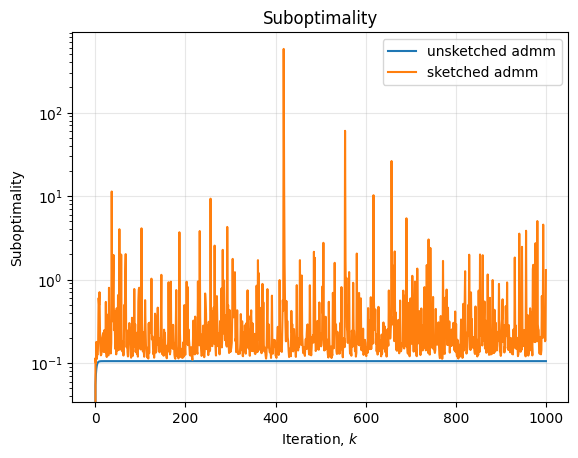

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.semilogy(np.arange(max_iter), costs, label='unsketched admm')
plt.semilogy(np.arange(max_iter), sketch_costs, label='sketched admm')
# ax.set_xticks(np.arange(max_iter))
plt.xlabel('Iteration, $k$')
plt.ylabel('Suboptimality')
plt.title('Suboptimality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

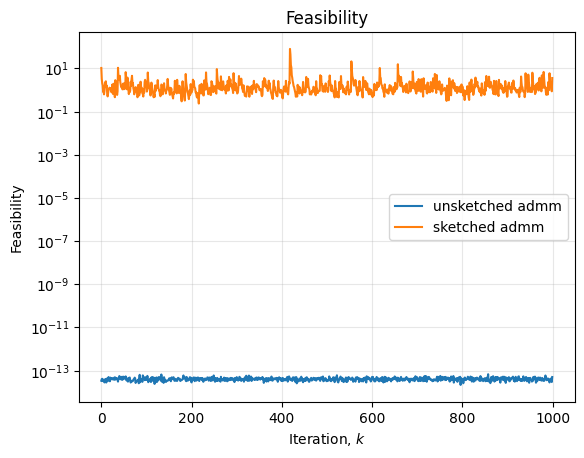

In [59]:

fig, ax = plt.subplots()
plt.semilogy(np.arange(max_iter), feas, label='unsketched admm')
plt.semilogy(np.arange(max_iter), sketch_feas, label='sketched admm')
# ax.set_xticks(np.arange(max_iter))
plt.xlabel('Iteration, $k$')
plt.ylabel('Feasibility')
plt.title('Feasibility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

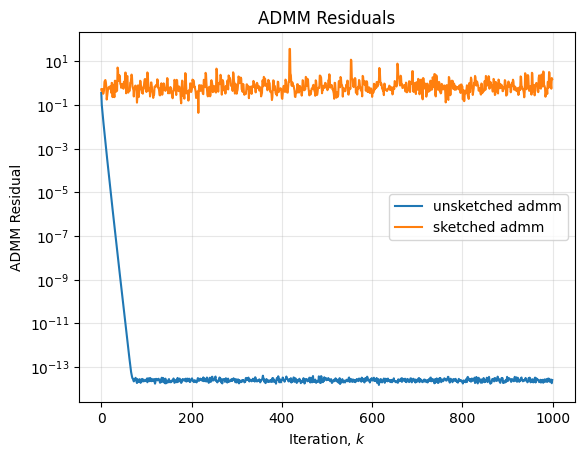

In [60]:

fig, ax = plt.subplots()
plt.semilogy(np.arange(max_iter), admm_res, label='unsketched admm')
plt.semilogy(np.arange(max_iter), sketch_admm_res, label='sketched admm')
# ax.set_xticks(np.arange(max_iter))
plt.xlabel('Iteration, $k$')
plt.ylabel('ADMM Residual')
plt.title('ADMM Residuals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()